# Análisis exploratorio de incidencia delictiva en México

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [25]:
df = pd.read_csv('data/delitos.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/delitos.csv'

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

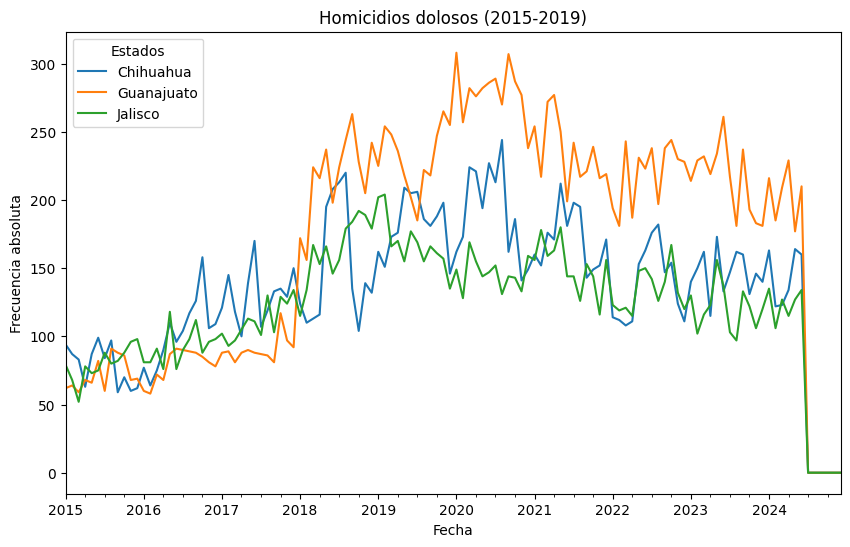

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/datos_delitos.csv', encoding='latin-1')

estados = ["Jalisco", "Guanajuato", "Chihuahua"]

df_estados = df[df["Entidad"].isin(estados)]
df_estados = df_estados[df_estados["Subtipo de delito"] == "Homicidio doloso"]

meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio",
         "Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

df_melt = df_estados.melt(
    id_vars=["Año","Entidad"],
    value_vars=meses,
    var_name="Mes",
    value_name="Homicidios"
)


mapa_meses = {
    "Enero":1,"Febrero":2,"Marzo":3,"Abril":4,"Mayo":5,"Junio":6,
    "Julio":7,"Agosto":8,"Septiembre":9,"Octubre":10,"Noviembre":11,"Diciembre":12
}

df_melt["Mes_num"] = df_melt["Mes"].map(mapa_meses)


df_melt["Fecha"] = pd.to_datetime(dict(year=df_melt["Año"], month=df_melt["Mes_num"], day=1))

serie = df_melt.groupby(["Fecha","Entidad"])["Homicidios"].sum().unstack()

serie.plot(figsize=(10,6))

plt.title("Homicidios dolosos (2015-2019)")
plt.xlabel("Fecha")
plt.ylabel("Frecuencia absoluta")
plt.legend(title="Estados")

plt.show()

#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [ ]:
import pandas as pd

df = pd.read_csv('data/datos_delitos.csv', encoding='latin-1')

meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio",
         "Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

# -------------------------------------------------
# 1. ¿Cuántos homicidios dolosos hubo en Colima en 2018?
# -------------------------------------------------

colima_2018 = df[
    (df["Entidad"] == "Colima") &
    (df["Subtipo de delito"] == "Homicidio doloso") &
    (df["Año"] == 2018)
]

total_colima_2018 = colima_2018[meses].sum().sum()

print("1) Homicidios dolosos en Colima en 2018:", total_colima_2018)


# -------------------------------------------------
# 2. ¿Cuántos robos de vehículo automotor hubo en 2019?
# -------------------------------------------------

robo_2019 = df[
    (df["Subtipo de delito"] == "Robo de vehículo automotor") &
    (df["Año"] == 2019)
]

total_robo_2019 = robo_2019[meses].sum().sum()

print("2) Robos de vehículo automotor en 2019:", total_robo_2019)


# -------------------------------------------------
# 3. Suma de homicidios dolosos y feminicidios por año
# -------------------------------------------------

delitos = df[df["Subtipo de delito"].isin(["Homicidio doloso", "Feminicidio"])]

suma_anual = delitos.groupby("Año")[meses].sum().sum(axis=1)

print("\n3) Suma de homicidios dolosos y feminicidios por año:")
print(suma_anual)


# -------------------------------------------------
# 4. Mes y estado con mayor número de feminicidios
# -------------------------------------------------

feminicidio = df[df["Subtipo de delito"] == "Feminicidio"]

fem_melt = feminicidio.melt(
    id_vars=["Entidad","Año"],
    value_vars=meses,
    var_name="Mes",
    value_name="Casos"
)

max_fem = fem_melt.loc[fem_melt["Casos"].idxmax()]

print("\n4) Mayor número de feminicidios:")
print("Estado:", max_fem["Entidad"])
print("Año:", max_fem["Año"])
print("Mes:", max_fem["Mes"])
print("Casos:", max_fem["Casos"])


# -------------------------------------------------
# 5. Año y estado con mayor número de feminicidios
# -------------------------------------------------

suma_estado_año = feminicidio.groupby(["Año","Entidad"])[meses].sum().sum(axis=1)

max_estado_año = suma_estado_año.idxmax()
max_valor = suma_estado_año.max()

print("\n5) Año y estado con más feminicidios:")
print("Año:", max_estado_año[0])
print("Estado:", max_estado_año[1])
print("Casos:", max_valor)

1) Homicidios dolosos en Colima en 2018: 617.0
2) Robos de vehículo automotor en 2019: 187661.0

3) Suma de homicidios dolosos y feminicidios por año:
Año
2015    16532.0
2016    20756.0
2017    25777.0
2018    29995.0
2019    30445.0
2020    29786.0
2021    29263.0
2022    27240.0
2023    26119.0
2024    13255.0
dtype: float64

4) Mayor número de feminicidios:
Estado: Veracruz de Ignacio de la Llave
Año: 2018
Mes: Abril
Casos: 16.0

5) Año y estado con más feminicidios:
Año: 2020
Estado: México
Casos: 151.0


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

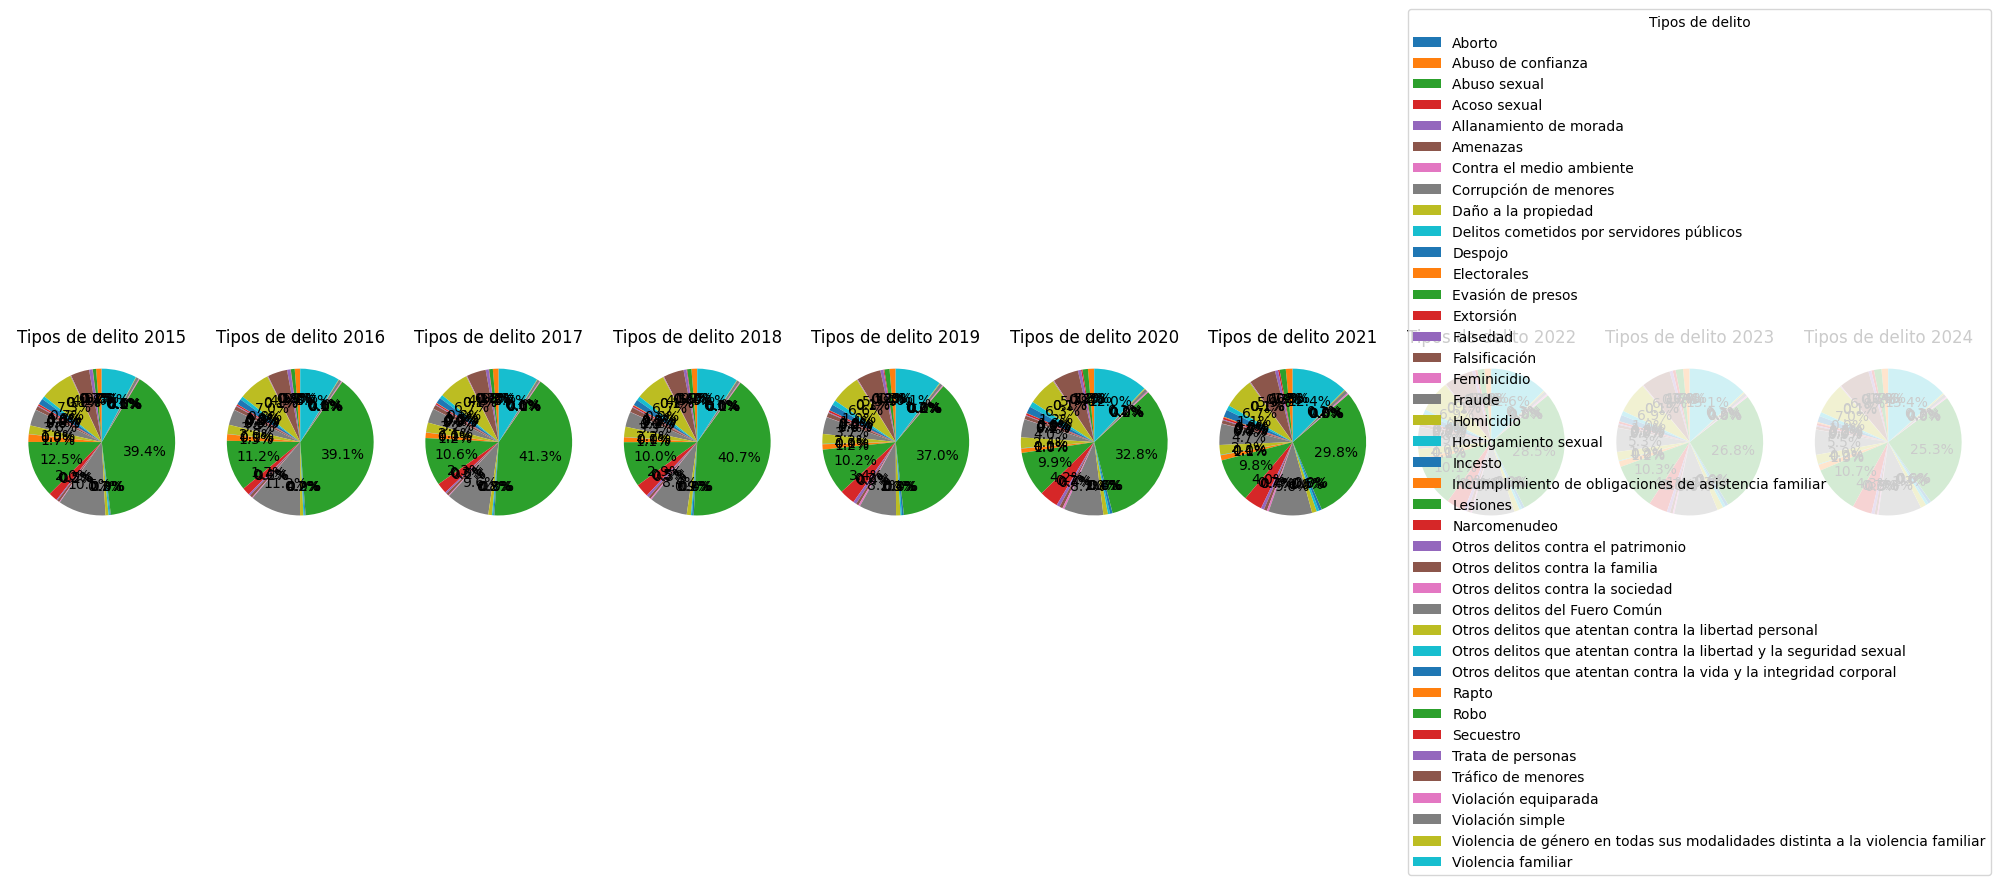

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/datos_delitos.csv', encoding='latin-1')

meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio",
         "Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

df["Total"] = df[meses].sum(axis=1)

datos = df.groupby(["Año","Tipo de delito"])["Total"].sum()

años = sorted(df["Año"].unique())

fig, axes = plt.subplots(1, len(años), figsize=(20,6))

for i, año in enumerate(años):

    data_año = datos[año]

    wedges, texts, autotexts = axes[i].pie(
        data_año,
        autopct='%1.1f%%',
        startangle=90
    )

    axes[i].set_title(f"Tipos de delito {año}")

# leyenda general
fig.legend(
    wedges,
    data_año.index,
    title="Tipos de delito",
    loc="center right"
)

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [ ]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()


KeyError: 'clave_entidad'

In [31]:
print(pobs.columns)
print(delitos_entidad.columns)

Index(['Unnamed: 0', 'Cve_Entidad', 'Entidad', 'Poblacion'], dtype='str')
Index(['clave_entidad', 'total_delitos'], dtype='str')


In [42]:
import pandas as pd

# 1. Cargar datos
datos = pd.read_csv('data/datos_delitos.csv', encoding='iso-8859-1')
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=';')

# 2. Limpiar nombres de columnas (quitar espacios y convertir a minúsculas)
datos.columns = datos.columns.str.strip().str.lower()
pobs.columns = pobs.columns.str.strip().str.lower().str.replace(' ', '_')

# 3. Lista de meses (convertir a minúsculas para coincidir)
meses = ['enero','febrero','marzo','abril','mayo','junio',
         'julio','agosto','septiembre','octubre','noviembre','diciembre']

# 4. Total anual de delitos
datos['total_delitos'] = datos[meses].sum(axis=1)

# 5. Agrupar por entidad
delitos_entidad = datos.groupby('clave_ent', as_index=False)['total_delitos'].sum()

# 6. Merge con población usando nombres limpios
df = delitos_entidad.merge(
    pobs,
    left_on='clave_ent',
    right_on='cve_entidad',  # columna limpia de población
    how='left'
)

# 7. Calcular tasas
df['tasa_100k'] = (df['total_delitos'] / df['poblacion']) * 100000
df['tasa_anualizada'] = df['tasa_100k'] * 12

# 8. Ordenar y mostrar top 10
df = df.sort_values('tasa_anualizada', ascending=False)
df.head(10)

,clave_ent,total_delitos,unnamed:_0,cve_entidad,entidad,poblacion,tasa_100k,tasa_anualizada
8,9,2040461.0,8,9,Ciudad de México,711235.0,286889.846535,3.442678e+06
1,2,1027969.0,1,2,Baja California,3315766.0,31002.459160,3.720295e+05
2,3,208528.0,2,3,Baja California Sur,712029.0,29286.447603,3.514374e+05
22,23,378981.0,22,23,Quintana Roo,1501562.0,25239.117665,3.028694e+05
0,1,330860.0,0,1,Aguascalientes,1312544.0,25207.535900,3.024904e+05
21,22,505865.0,21,22,Querétaro,2038372.0,24817.108948,2.978053e+05
16,17,424229.0,16,17,Morelos,1903811.0,22283.146804,2.673978e+05
7,8,655170.0,7,8,Chihuahua,2954915.0,22172.211383,2.660665e+05
14,15,3392550.0,14,15,México,16187608.0,20957.698012,2.514924e+05
26,27,498041.0,26,27,Tabasco,2395272.0,20792.669893,2.495120e+05
